# XGBoost

In [1]:
from dotenv import load_dotenv
from mlModels.regression.data.data import getData, getRegressionData
from database.db import getConnection
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor as xgbr
from utils.enums import Mappings, Listings, Features
from sklearn.cluster import KMeans
from mlModels.kmeans.locationClustering import findBestFittingK, projectCoords
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.chdir("/home/florian/Desktop/immopreis-regression")

load_dotenv("database/.env")
conn = getConnection()

df = getData(filter_type=Listings.FINANCE_TYPE, filter_val="buy")
conn.close()


# Location ppm2 mean

w_postcode = n_postcode / (n_postcode + k1)

w_cluster_raw = n_cluster / (n_cluster + k2)

w_cluster = (1 - w_postcode) * w_cluster_raw

w_global = (1 - w_postcode) * (1 - w_cluster_raw)

In [2]:
postcode_trust = 15
cluster_trust = 15
global_ppm2_mean = df[Features.PPM2].mean()

# Postcodes
postcode_stats = df.groupby(Listings.POSTCODE)[Features.PPM2].agg(["mean", "count"])
postcode_stats.columns = ["postcode_mean", "postcode_count"]
df = df.merge(postcode_stats, on=Listings.POSTCODE, how="left")



### K-Mean Cluster Mean

calculated k's: 13, 97, 99

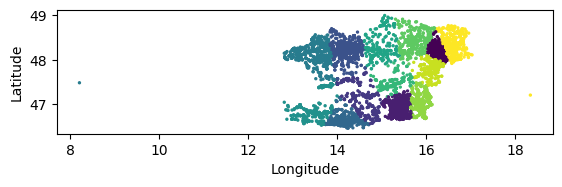

In [3]:
df_cluster_mean = pd.DataFrame()

df_cluster_data = df[[Listings.ID, Listings.LAT, Listings.LON, Features.PPM2]].copy()
df_cluster_data.drop(
    df_cluster_data[lambda d: (d[Listings.LAT] < 40) | (d[Listings.LON] < 5)].index,
    inplace=True
)

coords = df_cluster_data[[Listings.LON, Listings.LAT]].values


kmeans = KMeans(n_clusters=13, random_state=42)
labels = kmeans.fit_predict(coords)
df_cluster_data["cluster"] = labels
means = df_cluster_data.groupby("cluster")[Features.PPM2].mean()
df_cluster_data["cluster_mean"] = df_cluster_data["cluster"].map(means)
df_cluster_mean = df_cluster_data[[Listings.ID, "cluster", "cluster_mean"]].copy()

plt.figure()
plt.gca().set_aspect('equal', adjustable='box')
plt.scatter(coords[:, 0], coords[:, 1], c=labels, s=2)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

df = df.merge(df_cluster_mean, on=Listings.ID, how="left")
cluster_counts = df.groupby("cluster")[Features.PPM2].count().rename("cluster_count")
df = df.merge(cluster_counts, on="cluster", how="left")



### Calc cluster means

In [4]:
df["w_postcode"] = df["postcode_count"] / (df["postcode_count"] + postcode_trust)
df["w_cluster_raw"] = df["cluster_count"] / (df["cluster_count"] + cluster_trust)
df["w_cluster"] = (1 - df["w_postcode"]) * df["w_cluster_raw"]
df["w_global"] = (1 - df["w_postcode"]) * (1 - df["w_cluster_raw"])
df["location_cluster_mean_ppm2"] = (
    df["w_postcode"] * df["postcode_mean"]
    + df["w_cluster"] * df["cluster_mean"]
    + df["w_global"] * global_ppm2_mean
)

print(df["location_cluster_mean_ppm2"].describe())

count    22989.0
mean         inf
std          NaN
min          inf
25%          NaN
50%          NaN
75%          NaN
max          inf
Name: location_cluster_mean_ppm2, dtype: float64


/home/florian/Desktop/immopreis-regression/.venv/lib64/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/florian/Desktop/immopreis-regression/.venv/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


### Location Cleanup

In [5]:
df.drop(columns=["w_postcode", "postcode_count", "w_cluster_raw", "cluster_count",
                 "w_cluster", "cluster", "cluster_mean", "w_global", "postcode_mean"], inplace=True)

# Prepare df

In [6]:
df = df.dropna(subset=["rooms"])
df = df.drop(columns=[Listings.ID, Listings.HWB, Listings.HWB_CLASS, Listings.FGEE, Listings.FGEE_CLASS, Listings.POSTCODE])
df.drop(columns=[c for c in df.columns if c.startswith("state_")], inplace=True)
df.drop_duplicates(subset=[Listings.LAT, Listings.LON, Features.PPM2], inplace=True)

# Drop POI counter -> leakage
#df.drop(columns=[c for c in df.columns if c.startswith("log_count_poi_")], inplace=True)
print("Num duplicated: " + str(df.duplicated(subset=[Listings.LAT, Listings.LON, Features.PPM2]).sum()))

# split into house and apt data
# houses
df_house = df[df[Listings.PROPERTY_TYPE].isin(Mappings.HOUSE_COLS)].copy()
df_y_house = df_house[Features.PPM2]
df_house.drop(columns=[Listings.PROPERTY_TYPE, Features.PPM2], inplace=True)
df_X_house = df_house

# apt
df_apt = df[df[Listings.PROPERTY_TYPE].isin(Mappings.APARTMENT_COLS)].copy()
df_y_apt = df_apt[Features.PPM2]
df_apt.drop(columns=[Listings.PROPERTY_TYPE, Features.PPM2], inplace=True)
df_X_apt = df_apt

X_train, X_test, y_train, y_test = train_test_split(df_X_house, df_y_house, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(df_X_apt, df_y_apt, test_size=0.2, random_state=42)

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
mask = ~np.isinf(y_train)
y_train = y_train[mask]

Num duplicated: 0


# KNN Features

In [7]:
def knnFeature(_X_train_coords, _X_query_coords, _y_values, _k):
    _knn = NearestNeighbors(n_neighbors=_k+1, metric="haversine")
    _knn.fit(X_train_coords)

    _distances, _indices = _knn.kneighbors(_X_query_coords)

    if _X_query_coords is _X_train_coords:
        _distances = _distances[:, 1:]
        _indices = _indices[:, 1:]

    _weights = 1 / (_distances + 1e-8)

    return np.sum(_weights * _y_values[_indices], axis=1) / np.sum(_weights, axis=1)

### KNN --- Training data ---

In [8]:
# --- TRAIN ---
X_train_coords = np.radians(X_train[[Listings.LAT, Listings.LON]].values)
y_values = y_train.values

X_train["knn_k5"] = knnFeature(X_train_coords, X_train_coords, y_values, 5)
X_train["knn_k20"] = knnFeature(X_train_coords, X_train_coords, y_values, 20)
X_train["knn_k50"] = knnFeature(X_train_coords, X_train_coords, y_values, 50)


### KNN --- Test data ---

In [9]:
# --- TEST ---
X_test_coords = np.radians(X_test[[Listings.LAT, Listings.LON]].values)

X_test["knn_k5"] = knnFeature(X_train_coords, X_test_coords, y_values, 5)
X_test["knn_k20"] = knnFeature(X_train_coords, X_test_coords, y_values, 20)
X_test["knn_k50"] = knnFeature(X_train_coords, X_test_coords, y_values, 50)

### KNN Cleanup

In [10]:
X_test.drop(columns=[Listings.LAT, Listings.LON, Listings.ROOMS], inplace=True)
X_train.drop(columns=[Listings.LAT, Listings.LON, Listings.ROOMS], inplace=True)

# XGBoost

In [11]:

model = xgbr(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)

model.fit(X_train, y_train)
model.predict(X_test)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

df_feature_importances = pd.DataFrame(
    {"feature": X_train.columns, "importance": model.feature_importances_}
)

df_feature_importances = df_feature_importances.sort_values(
    by="importance", ascending=False
)

print(df_feature_importances)



                         feature  importance
31               log_loggia_size    0.102018
28              log_balcony_size    0.092572
30              log_terrace_size    0.071375
35                       knn_k20    0.069023
23       log_distance_to_tourism    0.065539
34                        knn_k5    0.065085
7                     has_closet    0.064724
36                       knn_k50    0.053200
29               log_garden_size    0.050647
0                    living_area    0.047304
26            log_count_poi_10km    0.045852
4                     has_garage    0.042270
21  log_distance_to_nearest_city    0.039601
24    log_distance_train_station    0.032319
2                   has_elevator    0.032257
15                      is_floor    0.030945
5                     has_cellar    0.025401
27            log_count_poi_25km    0.024232
22    log_distance_to_major_city    0.021954
25             log_count_poi_5km    0.019449
14                is_air_heating    0.002388
6         

# Output

In [12]:
print("Holdout Results")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")
for k in (5, 20, 50):
    print(f"KNN_k{k} corr:", np.corrcoef(X_train[f"knn_k{k}"], y_train)[0, 1])
    knnkx = "knn_k" + str(k)
    print(X_train[knnkx].describe())
    print(X_test[knnkx].describe())



Holdout Results
MAE:  38.9125
RMSE: 620.0971
R2:   -0.1052
KNN_k5 corr: 0.19302719248494987
count    9500.000000
mean       33.141057
std       215.123041
min         6.907335
25%        12.032368
50%        12.583517
75%        12.939391
max      7770.062327
Name: knn_k5, dtype: float64
count    2375.000000
mean       36.043001
std       211.870368
min         7.544481
25%        12.035276
50%        12.589794
75%        12.942879
max      5391.335815
Name: knn_k5, dtype: float64
KNN_k20 corr: 0.29645124084950336
count    9500.000000
mean       29.816045
std       205.056655
min         7.020839
25%        12.108087
50%        12.612960
75%        12.935073
max      9738.483170
Name: knn_k20, dtype: float64
count    2375.000000
mean       29.341763
std       155.075707
min         7.560142
25%        12.141079
50%        12.629001
75%        12.935937
max      5339.442561
Name: knn_k20, dtype: float64
KNN_k50 corr: 0.25212505719724865
count    9500.000000
mean       29.022283
std     